## Name: Omkar Khilare
## PRN : 202301040302

# Neural Network Implementation: Perceptron, Feedforward, and Backpropagation
## Predictive Analytics Course Assignment

This notebook implements neural networks from scratch and demonstrates:
1. **Perceptron** - Basic neural network unit
2. **Feedforward Network** - Multi-layer neural network
3. **Backpropagation** - Training algorithm


### Dataset : Red wine quality
 https://www.kaggle.com/datasets/uciml/red-wine-quality-cortez-et-al-2009

- Contains 1,599 red wine samples with 11 physicochemical features and quality ratings (0-10)

## Step 1: Import Required Libraries

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, roc_auc_score
import warnings
import os
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

print("All libraries imported successfully!")

All libraries imported successfully!


## Step 1b: GPU Setup and Detection

In [16]:
# Check GPU availability and setup
print("GPU Configuration:")
print("=" * 60)

# Check CUDA availability with PyTorch
try:
    import torch
    cuda_available = torch.cuda.is_available()
    device_count = torch.cuda.device_count()
    print(f"PyTorch CUDA Available: {cuda_available}")
    if cuda_available:
        print(f"CUDA Devices: {device_count}")
        print(f"Current Device: {torch.cuda.get_device_name(0)}")
        print(f"CUDA Version: {torch.version.cuda}")
    GPU_AVAILABLE = cuda_available
except ImportError:
    print("PyTorch not installed")
    GPU_AVAILABLE = False

# Try CuPy (optional, for advanced GPU computing)
CUPY_AVAILABLE = False
try:
    import cupy as cp
    CUPY_AVAILABLE = True
    print(f"\nCuPy Available: True")
    gpu_device = cp.cuda.Device()
    print(f"GPU Device: {gpu_device}")
except ImportError:
    print("\nCuPy not available (using PyTorch GPU tensors instead)")

print("=" * 60)
print(f"\n✓ GPU Training: {'ENABLED' if GPU_AVAILABLE else 'CPU MODE'}")

# Set device for PyTorch if available
if GPU_AVAILABLE:
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"✓ Training Device: {DEVICE}")
    print(f"✓ Using: PyTorch GPU Tensors")
else:
    DEVICE = None
    print("Using CPU for training")

GPU Configuration:
PyTorch CUDA Available: True
CUDA Devices: 1
Current Device: NVIDIA GeForce RTX 4060 Laptop GPU
CUDA Version: 12.1

CuPy not available (using PyTorch GPU tensors instead)

✓ GPU Training: ENABLED
✓ Training Device: cuda
✓ Using: PyTorch GPU Tensors


## Step 2: Load and Explore the Wine Quality Dataset

We'll use the **Wine Quality Dataset** (Red Wine) containing:
- 1,599 samples
- 11 features (physicochemical properties: acidity, alcohol, sulfates, etc.)
- 1 target (quality score 0-10) → converted to binary (good vs bad wine)
- Binary classification: Quality >= 6 is "Good", < 6 is "Bad"

In [8]:
# Download Wine Quality Dataset from Kaggle
# If you haven't downloaded it yet, download from:
# https://www.kaggle.com/datasets/uciml/red-wine-quality-cortez-et-al-2009

# Specify the path to your downloaded file
csv_path = 'winequality-red.csv'

# If file doesn't exist, provide download instructions
if not os.path.exists(csv_path):
    print("Wine Quality dataset not found!")
    print("\nPlease download from Kaggle:")
    print("https://www.kaggle.com/datasets/uciml/red-wine-quality-cortez-et-al-2009")
    print(f"\nSave the file as '{csv_path}' in your working directory")
    print("\nOr use this code to load from URL:")
    print("import urllib.request")
    print("url = 'https://raw.githubusercontent.com/uiuc-cse/data-fa14/gh-pages/data/wine.csv'")
    print("urllib.request.urlretrieve(url, 'winequality-red.csv')")
else:
    # Load the dataset
    df = pd.read_csv(csv_path)
    
    # Display dataset info
    print("Dataset Information:")
    print(f"Shape: {df.shape}")
    print(f"Features: {list(df.columns[:-1])}")
    print(f"\nFirst few rows:")
    print(df.head())
    
    # Extract features and target
    X = df.iloc[:, :-1].values  # All columns except the last one
    y_quality = df.iloc[:, -1].values  # Quality column
    
    # Convert to binary classification: Good (1) if quality >= 6, Bad (0) if < 6
    y = (y_quality >= 6).astype(int)
    
    print(f"\n✓ Data loaded and processed!")
    print(f"Features shape: {X.shape}")
    print(f"Labels shape: {y.shape}")

Dataset Information:
Shape: (1599, 12)
Features: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']

First few rows:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65 

### Visualize the Dataset

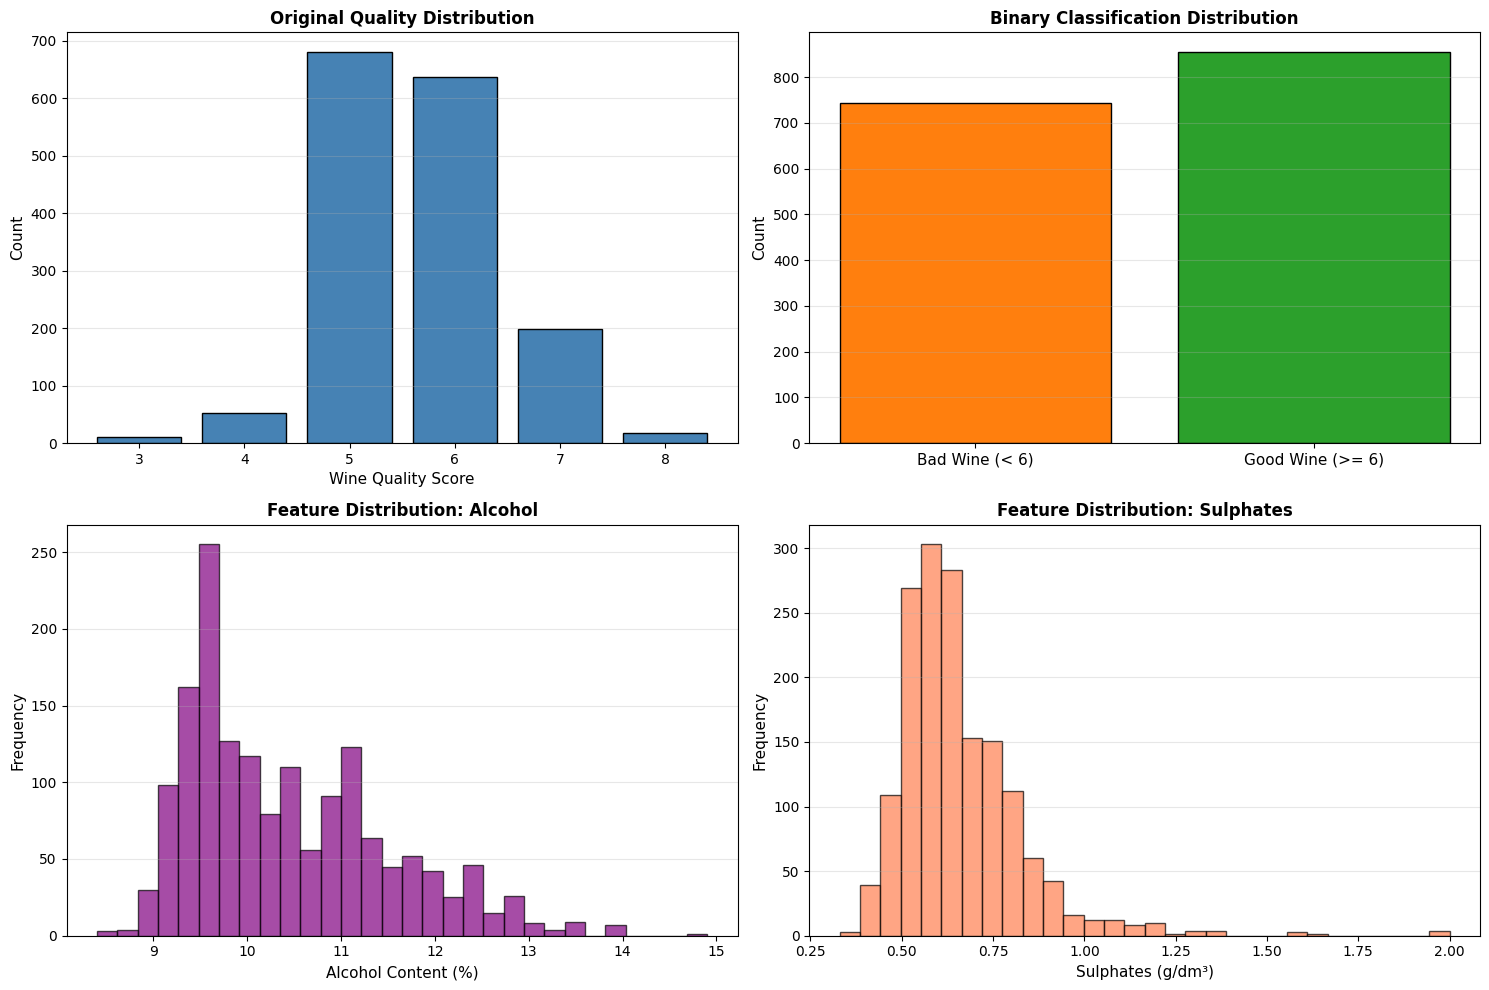


Dataset Statistics:
       fixed acidity  volatile acidity  citric acid  residual sugar  \
count    1599.000000       1599.000000  1599.000000     1599.000000   
mean        8.319637          0.527821     0.270976        2.538806   
std         1.741096          0.179060     0.194801        1.409928   
min         4.600000          0.120000     0.000000        0.900000   
25%         7.100000          0.390000     0.090000        1.900000   
50%         7.900000          0.520000     0.260000        2.200000   
75%         9.200000          0.640000     0.420000        2.600000   
max        15.900000          1.580000     1.000000       15.500000   

         chlorides  free sulfur dioxide  total sulfur dioxide      density  \
count  1599.000000          1599.000000           1599.000000  1599.000000   
mean      0.087467            15.874922             46.467792     0.996747   
std       0.047065            10.460157             32.895324     0.001887   
min       0.012000         

In [9]:
# Visualize the dataset
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Quality distribution
quality_counts = pd.Series(y_quality).value_counts().sort_index()
axes[0, 0].bar(quality_counts.index, quality_counts.values, color='steelblue', edgecolor='black')
axes[0, 0].set_xlabel('Wine Quality Score', fontsize=11)
axes[0, 0].set_ylabel('Count', fontsize=11)
axes[0, 0].set_title('Original Quality Distribution', fontsize=12, fontweight='bold')
axes[0, 0].grid(axis='y', alpha=0.3)

# Binary class distribution
binary_counts = pd.Series(y).value_counts().sort_index()
class_names = ['Bad Wine (< 6)', 'Good Wine (>= 6)']
colors = ['#ff7f0e', '#2ca02c']
axes[0, 1].bar(range(len(binary_counts)), binary_counts.values, color=colors, edgecolor='black')
axes[0, 1].set_xticks(range(len(binary_counts)))
axes[0, 1].set_xticklabels(class_names, fontsize=11)
axes[0, 1].set_ylabel('Count', fontsize=11)
axes[0, 1].set_title('Binary Classification Distribution', fontsize=12, fontweight='bold')
axes[0, 1].grid(axis='y', alpha=0.3)

# Feature distributions (first 2 important features)
feature_names = list(df.columns[:-1])
alcohol_data = X[:, 10]  # Alcohol content (usually important)
sulphates_data = X[:, 9]  # Sulphates (usually important)

axes[1, 0].hist(alcohol_data, bins=30, color='purple', alpha=0.7, edgecolor='black')
axes[1, 0].set_xlabel('Alcohol Content (%)', fontsize=11)
axes[1, 0].set_ylabel('Frequency', fontsize=11)
axes[1, 0].set_title('Feature Distribution: Alcohol', fontsize=12, fontweight='bold')
axes[1, 0].grid(axis='y', alpha=0.3)

axes[1, 1].hist(sulphates_data, bins=30, color='coral', alpha=0.7, edgecolor='black')
axes[1, 1].set_xlabel('Sulphates (g/dm³)', fontsize=11)
axes[1, 1].set_ylabel('Frequency', fontsize=11)
axes[1, 1].set_title('Feature Distribution: Sulphates', fontsize=12, fontweight='bold')
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nDataset Statistics:")
print(df.describe())

In [ ]:
# Visualize the Wine Quality dataset
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Quality distribution
axes[0, 0].hist(y_quality, bins=range(3, 10), color='wine', alpha=0.7, edgecolor='black')
axes[0, 0].axvline(x=6, color='red', linestyle='--', linewidth=2, label='Classification threshold')
axes[0, 0].set_xlabel('Quality Score')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Wine Quality Score Distribution')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Class distribution (Binary)
class_counts = [np.sum(y == 0), np.sum(y == 1)]
colors = ['#FF6B6B', '#4ECDC4']
axes[0, 1].bar(['Bad Wine', 'Good Wine'], class_counts, color=colors, alpha=0.7, edgecolor='black')
axes[0, 1].set_ylabel('Count')
axes[0, 1].set_title('Binary Classification Distribution')
axes[0, 1].grid(True, alpha=0.3, axis='y')

# 3. Alcohol content by class
bad_wine_alcohol = X[y == 0, 10]  # Alcohol is the last feature
good_wine_alcohol = X[y == 1, 10]
axes[1, 0].hist(bad_wine_alcohol, bins=20, alpha=0.6, label='Bad Wine', color='#FF6B6B', edgecolor='black')
axes[1, 0].hist(good_wine_alcohol, bins=20, alpha=0.6, label='Good Wine', color='#4ECDC4', edgecolor='black')
axes[1, 0].set_xlabel('Alcohol Content (%)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Alcohol Content Distribution by Class')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. Acidity vs Alcohol
axes[1, 1].scatter(X[y == 0, 1], X[y == 0, 10], alpha=0.6, label='Bad Wine', color='#FF6B6B', s=50)
axes[1, 1].scatter(X[y == 1, 1], X[y == 1, 10], alpha=0.6, label='Good Wine', color='#4ECDC4', s=50)
axes[1, 1].set_xlabel('Volatile Acidity')
axes[1, 1].set_ylabel('Alcohol Content')
axes[1, 1].set_title('Volatile Acidity vs Alcohol Content')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nDataset statistics:")
print(df_processed.describe())

## Step 3: Implement Activation Functions

Activation functions introduce non-linearity to neural networks, allowing them to learn complex patterns.

In [23]:
class ActivationFunctions:
    """Collection of activation functions and their derivatives"""
    
    @staticmethod
    def sigmoid(x):
        """Sigmoid activation function: 1 / (1 + e^(-x))"""
        if isinstance(x, torch.Tensor):
            return 1 / (1 + torch.exp(-torch.clamp(x, -500, 500)))
        else:
            return 1 / (1 + np.exp(-np.clip(x, -500, 500)))
    
    @staticmethod
    def sigmoid_derivative(x):
        """Derivative of sigmoid: σ'(x) = σ(x) * (1 - σ(x))"""
        return x * (1 - x)
    
    @staticmethod
    def relu(x):
        """ReLU activation: max(0, x)"""
        if isinstance(x, torch.Tensor):
            return torch.maximum(torch.tensor(0.0, device=x.device), x)
        else:
            return np.maximum(0, x)
    
    @staticmethod
    def relu_derivative(x):
        """Derivative of ReLU"""
        if isinstance(x, torch.Tensor):
            return (x > 0).float()
        else:
            return (x > 0).astype(float)
    
    @staticmethod
    def tanh(x):
        """Tanh activation function"""
        if isinstance(x, torch.Tensor):
            return torch.tanh(x)
        else:
            return np.tanh(x)
    
    @staticmethod
    def tanh_derivative(x):
        """Derivative of tanh: tanh'(x) = 1 - tanh²(x)"""
        return 1 - x**2
    
    @staticmethod
    def softmax(x):
        """Softmax activation for multi-class output"""
        if isinstance(x, torch.Tensor):
            exp_x = torch.exp(x - torch.max(x, dim=1, keepdim=True)[0])
            return exp_x / torch.sum(exp_x, dim=1, keepdim=True)
        else:
            exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
            return exp_x / np.sum(exp_x, axis=1, keepdims=True)
    
    @staticmethod
    def linear(x):
        """Linear activation (identity)"""
        return x

print("Activation functions defined (with GPU support)!")

Activation functions defined (with GPU support)!


### Visualize Activation Functions

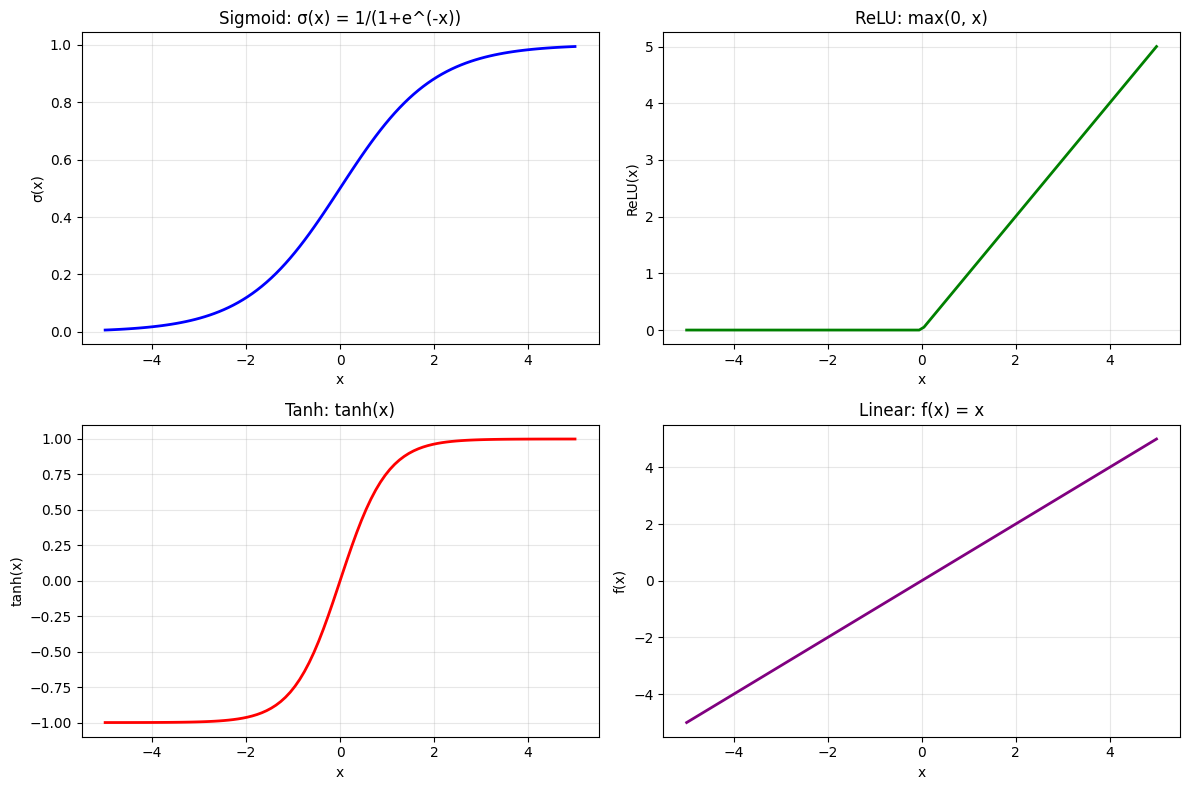

In [31]:
# Plot activation functions
x = np.linspace(-5, 5, 100)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Sigmoid
y_sigmoid = ActivationFunctions.sigmoid(x)
axes[0, 0].plot(x, y_sigmoid, 'b-', linewidth=2)
axes[0, 0].set_title('Sigmoid: σ(x) = 1/(1+e^(-x))')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_xlabel('x')
axes[0, 0].set_ylabel('σ(x)')

# ReLU
y_relu = ActivationFunctions.relu(x)
axes[0, 1].plot(x, y_relu, 'g-', linewidth=2)
axes[0, 1].set_title('ReLU: max(0, x)')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_xlabel('x')
axes[0, 1].set_ylabel('ReLU(x)')

# Tanh
y_tanh = ActivationFunctions.tanh(x)
axes[1, 0].plot(x, y_tanh, 'r-', linewidth=2)
axes[1, 0].set_title('Tanh: tanh(x)')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_xlabel('x')
axes[1, 0].set_ylabel('tanh(x)')

# Linear
y_linear = ActivationFunctions.linear(x)
axes[1, 1].plot(x, y_linear, 'purple', linewidth=2)
axes[1, 1].set_title('Linear: f(x) = x')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_xlabel('x')
axes[1, 1].set_ylabel('f(x)')

plt.tight_layout()
plt.show()

## Step 4: Implement the Perceptron

A **perceptron** is a single neuron that performs:
1. **Forward pass**: `z = w·x + b`, `a = activation(z)`
2. **Backward pass**: Update weights based on gradients

$$z = w \cdot x + b$$
$$a = \sigma(z)$$

In [18]:
class Perceptron:
    """Single Perceptron (neuron) implementation"""
    
    def __init__(self, input_size, activation='sigmoid'):
        """
        Initialize a perceptron
        
        Parameters:
        -----------
        input_size : int
            Number of input features
        activation : str
            Activation function ('sigmoid', 'relu', 'tanh', 'linear')
        """
        self.input_size = input_size
        self.activation_name = activation
        
        # Initialize weights with small random values
        self.weights = np.random.randn(input_size) * 0.01
        self.bias = 0.0
        
        self._set_activation()
    
    def _set_activation(self):
        """Set activation function and its derivative"""
        activations = {
            'sigmoid': (ActivationFunctions.sigmoid, ActivationFunctions.sigmoid_derivative),
            'relu': (ActivationFunctions.relu, ActivationFunctions.relu_derivative),
            'tanh': (ActivationFunctions.tanh, ActivationFunctions.tanh_derivative),
            'linear': (ActivationFunctions.linear, lambda x: np.ones_like(x)),
        }
        
        if self.activation_name not in activations:
            raise ValueError(f"Unknown activation: {self.activation_name}")
        
        self.activation, self.activation_derivative = activations[self.activation_name]
    
    def forward(self, x):
        """
        Forward pass: z = w·x + b, a = activation(z)
        
        Returns:
        --------
        tuple: (activated_output, pre_activation)
        """
        self.input = x
        self.z = np.dot(x, self.weights) + self.bias  # Pre-activation
        self.a = self.activation(self.z)  # Activation
        return self.a, self.z
    
    def backward(self, delta, learning_rate):
        """
        Backward pass: Update weights and bias using gradient
        
        Parameters:
        -----------
        delta : float
            Gradient of loss with respect to output
        learning_rate : float
            Learning rate for weight updates
        """
        # Compute gradient for weights
        dW = delta * self.input
        
        # Update weights and bias
        self.weights -= learning_rate * dW
        self.bias -= learning_rate * delta
        
        # Return gradient for next layer
        return delta * self.weights

print("Perceptron class implemented!")

Perceptron class implemented!


## Step 5: Implement the Layer (Multiple Perceptrons)

A **layer** contains multiple perceptrons working in parallel. It performs matrix operations:
$$Z = XW + b$$
$$A = activation(Z)$$

In [19]:
class Layer:
    """Fully connected layer in neural network with GPU support"""
    
    def __init__(self, input_size, output_size, activation='sigmoid', use_gpu=False, device=None):
        """Initialize a layer"""
        self.input_size = input_size
        self.output_size = output_size
        self.activation_name = activation
        self.use_gpu = use_gpu
        self.device = device
        
        # Initialize weights and bias
        w_cpu = np.random.randn(input_size, output_size) * 0.01
        b_cpu = np.zeros((1, output_size))
        
        if self.use_gpu:
            self.weights = torch.FloatTensor(w_cpu).to(device)
            self.bias = torch.FloatTensor(b_cpu).to(device)
        else:
            self.weights = w_cpu
            self.bias = b_cpu
        
        self._set_activation()
    
    def _set_activation(self):
        """Set activation function and its derivative"""
        activations = {
            'sigmoid': (ActivationFunctions.sigmoid, ActivationFunctions.sigmoid_derivative),
            'relu': (ActivationFunctions.relu, ActivationFunctions.relu_derivative),
            'tanh': (ActivationFunctions.tanh, ActivationFunctions.tanh_derivative),
            'linear': (ActivationFunctions.linear, lambda x: np.ones_like(x) if not isinstance(x, torch.Tensor) else torch.ones_like(x)),
            'softmax': (ActivationFunctions.softmax, None),
        }
        
        self.activation, self.activation_derivative = activations[self.activation_name]
    
    def forward(self, x):
        """Forward pass through layer"""
        self.input = x
        
        if self.use_gpu:
            self.z = torch.matmul(x, self.weights) + self.bias
        else:
            self.z = np.dot(x, self.weights) + self.bias
        
        self.a = self.activation(self.z)
        return self.a
    
    def backward(self, delta, learning_rate):
        """Backward pass (Backpropagation)"""
        batch_size = self.input.shape[0]
        
        # Apply activation derivative
        if self.activation_derivative is not None:
            delta = delta * self.activation_derivative(self.a)
        
        # Compute gradients
        if self.use_gpu:
            dW = torch.matmul(self.input.T, delta) / batch_size
            db = torch.sum(delta, dim=0, keepdim=True) / batch_size
            dX = torch.matmul(delta, self.weights.T)
        else:
            dW = np.dot(self.input.T, delta) / batch_size
            db = np.sum(delta, axis=0, keepdims=True) / batch_size
            dX = np.dot(delta, self.weights.T)
        
        # Update weights and bias
        self.weights -= learning_rate * dW
        self.bias -= learning_rate * db
        
        return dX

print("Layer class with GPU support (PyTorch) implemented!")

Layer class with GPU support (PyTorch) implemented!


## Step 6: Implement the Feedforward Network with Backpropagation

A **feedforward network** stacks multiple layers and uses **backpropagation** to train.

In [20]:
class FeedforwardNetwork:
    """Feedforward Neural Network with Backpropagation and GPU Support"""
    
    def __init__(self, layer_sizes, activations=None, use_gpu=True):
        """
        Initialize feedforward network
        
        Parameters:
        -----------
        layer_sizes : list of int
            Network architecture
        activations : list of str
            Activation for each layer
        use_gpu : bool
            Use GPU if available (default: True)
        """
        if len(layer_sizes) < 2:
            raise ValueError("Need at least input and output layer")
        
        self.layer_sizes = layer_sizes
        self.num_layers = len(layer_sizes) - 1
        
        # GPU configuration
        self.use_gpu = use_gpu and GPU_AVAILABLE
        self.device = DEVICE if GPU_AVAILABLE else None
        
        if self.use_gpu:
            print(f"✓ Using GPU: {torch.cuda.get_device_name(0)}")
        else:
            print(f"✓ Using CPU")
        
        # Default activations
        if activations is None:
            activations = ['sigmoid'] * (self.num_layers - 1) + ['softmax']
        
        if len(activations) != self.num_layers:
            raise ValueError(f"Expected {self.num_layers} activations, got {len(activations)}")
        
        # Initialize layers
        self.layers = []
        for i in range(self.num_layers):
            layer = Layer(layer_sizes[i], layer_sizes[i + 1], activations[i], 
                         use_gpu=self.use_gpu, device=self.device)
            self.layers.append(layer)
        
        self.training_history = {'loss': [], 'accuracy': []}
    
    def _to_gpu(self, X):
        """Convert numpy array to GPU tensor if using GPU"""
        if self.use_gpu:
            return torch.FloatTensor(X).to(self.device)
        else:
            return X
    
    def _to_numpy(self, tensor):
        """Convert GPU tensor to numpy array"""
        if self.use_gpu:
            return tensor.detach().cpu().numpy()
        else:
            return tensor
    
    def forward(self, X):
        """Forward pass through entire network"""
        self.A = X
        for layer in self.layers:
            self.A = layer.forward(self.A)
        return self.A
    
    def backward(self, dA, learning_rate):
        """Backward pass (Backpropagation Algorithm)"""
        delta = dA
        for layer in reversed(self.layers):
            delta = layer.backward(delta, learning_rate)
    
    def compute_loss(self, y_pred, y_true):
        """Compute Cross-Entropy Loss"""
        if self.use_gpu:
            m = y_pred.shape[0]
            loss = -torch.sum(y_true * torch.log(y_pred + 1e-8)) / m
            return float(loss.item())
        else:
            m = y_pred.shape[0]
            loss = -np.sum(y_true * np.log(y_pred + 1e-8)) / m
            return float(loss)
    
    def compute_loss_derivative(self, y_pred, y_true):
        """Compute derivative of Cross-Entropy Loss"""
        return y_pred - y_true
    
    def train(self, X, y, epochs=100, learning_rate=0.1, batch_size=None, verbose=True):
        """Train network using Backpropagation"""
        # Convert to GPU tensors if using GPU
        X_gpu = self._to_gpu(X)
        y_gpu = self._to_gpu(y)
        
        if batch_size is None:
            batch_size = X_gpu.shape[0]
        
        num_samples = X_gpu.shape[0]
        
        import time
        start_time = time.time()
        
        for epoch in range(epochs):
            # Shuffle data
            if self.use_gpu:
                indices = torch.randperm(num_samples).to(self.device)
            else:
                indices = np.random.permutation(num_samples)
            
            X_shuffled = X_gpu[indices]
            y_shuffled = y_gpu[indices]
            
            epoch_loss = 0
            epoch_acc = 0
            num_batches = 0
            
            # Mini-batch training
            for i in range(0, num_samples, batch_size):
                X_batch = X_shuffled[i:i + batch_size]
                y_batch = y_shuffled[i:i + batch_size]
                
                # Forward pass
                y_pred = self.forward(X_batch)
                
                # Compute loss
                loss = self.compute_loss(y_pred, y_batch)
                epoch_loss += loss
                
                # Compute accuracy
                if self.use_gpu:
                    pred_classes = torch.argmax(y_pred, axis=1)
                    true_classes = torch.argmax(y_batch, axis=1)
                    acc = float(torch.mean((pred_classes == true_classes).float()).item())
                else:
                    acc = float(np.mean(np.argmax(y_pred, axis=1) == np.argmax(y_batch, axis=1)))
                epoch_acc += acc
                num_batches += 1
                
                # Backward pass
                dA = self.compute_loss_derivative(y_pred, y_batch)
                self.backward(dA, learning_rate)
            
            avg_loss = epoch_loss / num_batches
            avg_acc = epoch_acc / num_batches
            
            self.training_history['loss'].append(avg_loss)
            self.training_history['accuracy'].append(avg_acc)
            
            if verbose and (epoch + 1) % 20 == 0:
                elapsed = time.time() - start_time
                print(f"Epoch {epoch + 1}/{epochs} | Loss: {avg_loss:.6f} | Accuracy: {avg_acc:.4f} | Time: {elapsed:.2f}s")
    
    def predict(self, X):
        """Make predictions"""
        X_gpu = self._to_gpu(X)
        y_pred = self.forward(X_gpu)
        if self.use_gpu:
            return self._to_numpy(torch.argmax(y_pred, axis=1))
        else:
            return np.argmax(y_pred, axis=1)
    
    def predict_proba(self, X):
        """Get prediction probabilities"""
        X_gpu = self._to_gpu(X)
        y_pred = self.forward(X_gpu)
        if self.use_gpu:
            return self._to_numpy(y_pred)
        else:
            return y_pred

print("FeedforwardNetwork class with GPU support (PyTorch) implemented!")

FeedforwardNetwork class with GPU support (PyTorch) implemented!


## Step 7: Prepare the Data

Convert the Wine Quality dataset to the format needed by our neural network.

In [21]:
# Normalize features for better neural network training
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# For binary classification, we'll use one-hot encoding for consistency with the network architecture
# Good Wine (1) vs Bad Wine (0)
num_classes = 2  # Binary classification
y_one_hot = np.zeros((len(y), num_classes))
for i, label in enumerate(y):
    y_one_hot[i, label] = 1

# Split into train and test sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_one_hot, test_size=0.2, random_state=42
)

print("Data preparation complete!")
print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")
print(f"One-hot encoded labels shape: {y_one_hot.shape}")
print(f"\nTraining set class distribution:")
train_bad = np.sum(y_train[:, 0] == 1)
train_good = np.sum(y_train[:, 1] == 1)
print(f"  Bad Wine: {train_bad} ({train_bad/len(y_train)*100:.1f}%)")
print(f"  Good Wine: {train_good} ({train_good/len(y_train)*100:.1f}%)")

Data preparation complete!
Training set shape: (1279, 11)
Test set shape: (320, 11)
One-hot encoded labels shape: (1599, 2)

Training set class distribution:
  Bad Wine: 603 (47.1%)
  Good Wine: 676 (52.9%)


## Step 8: Train the Neural Network

Now we'll train our feedforward network using backpropagation!

In [24]:
# Create network: 11 inputs (wine features) -> 16 hidden -> 8 hidden -> 2 outputs (binary classification)
# Enable GPU acceleration if available
network = FeedforwardNetwork(
    layer_sizes=[11, 16, 8, 2],
    activations=['sigmoid', 'sigmoid', 'softmax'],
    use_gpu=True  # Enable GPU if available
)

print("\nNetwork Architecture:")
print(f"Input Features: 11 (Wine physicochemical properties)")
for i, layer in enumerate(network.layers):
    print(f"Layer {i+1}: {layer.input_size} -> {layer.output_size} ({layer.activation_name})")
print(f"\nOutput Classes: 2 (Bad Wine vs Good Wine)")
print(f"GPU Acceleration: {'ENABLED' if network.use_gpu else 'DISABLED (Using CPU)'}")

# Train with backpropagation
print("\n" + "="*60)
print("TRAINING NEURAL NETWORK")
print("="*60)
network.train(
    X_train, y_train, 
    epochs=300, 
    learning_rate=0.1, 
    batch_size=16,
    verbose=True
)

print("\nTraining completed!")

✓ Using GPU: NVIDIA GeForce RTX 4060 Laptop GPU

Network Architecture:
Input Features: 11 (Wine physicochemical properties)
Layer 1: 11 -> 16 (sigmoid)
Layer 2: 16 -> 8 (sigmoid)
Layer 3: 8 -> 2 (softmax)

Output Classes: 2 (Bad Wine vs Good Wine)
GPU Acceleration: ENABLED

TRAINING NEURAL NETWORK
Epoch 20/300 | Loss: 0.694139 | Accuracy: 0.5097 | Time: 1.76s
Epoch 40/300 | Loss: 0.694774 | Accuracy: 0.5223 | Time: 3.19s
Epoch 60/300 | Loss: 0.690323 | Accuracy: 0.5215 | Time: 4.63s
Epoch 80/300 | Loss: 0.527985 | Accuracy: 0.7365 | Time: 6.07s
Epoch 100/300 | Loss: 0.519974 | Accuracy: 0.7405 | Time: 7.51s
Epoch 120/300 | Loss: 0.518080 | Accuracy: 0.7530 | Time: 8.97s
Epoch 140/300 | Loss: 0.516176 | Accuracy: 0.7491 | Time: 10.45s
Epoch 160/300 | Loss: 0.511821 | Accuracy: 0.7530 | Time: 11.88s
Epoch 180/300 | Loss: 0.506737 | Accuracy: 0.7559 | Time: 13.28s
Epoch 200/300 | Loss: 0.498442 | Accuracy: 0.7640 | Time: 14.71s
Epoch 220/300 | Loss: 0.493326 | Accuracy: 0.7692 | Time: 16.

## Step 7b: Optional - Install GPU Libraries

Uncomment the cell below to install CuPy for GPU acceleration (requires NVIDIA GPU with CUDA):

In [ ]:
# Install GPU libraries (Uncomment to install)
# For CuPy installation, refer to: https://docs.cupy.dev/en/stable/install.html
# For CUDA 11.x:
# !pip install cupy-cuda11x
# For CUDA 12.x:
# !pip install cupy-cuda12x

# Check what was installed
print("\nInstalled GPU Libraries:")
print("- PyTorch with CUDA support")
try:
    import cupy
    print("- CuPy (GPU array library)")
except:
    print("- CuPy not installed (optional for advanced GPU acceleration)")
    print("\nTo install CuPy, visit: https://docs.cupy.dev/en/stable/install.html")

## Step 9: Visualize Training Progress

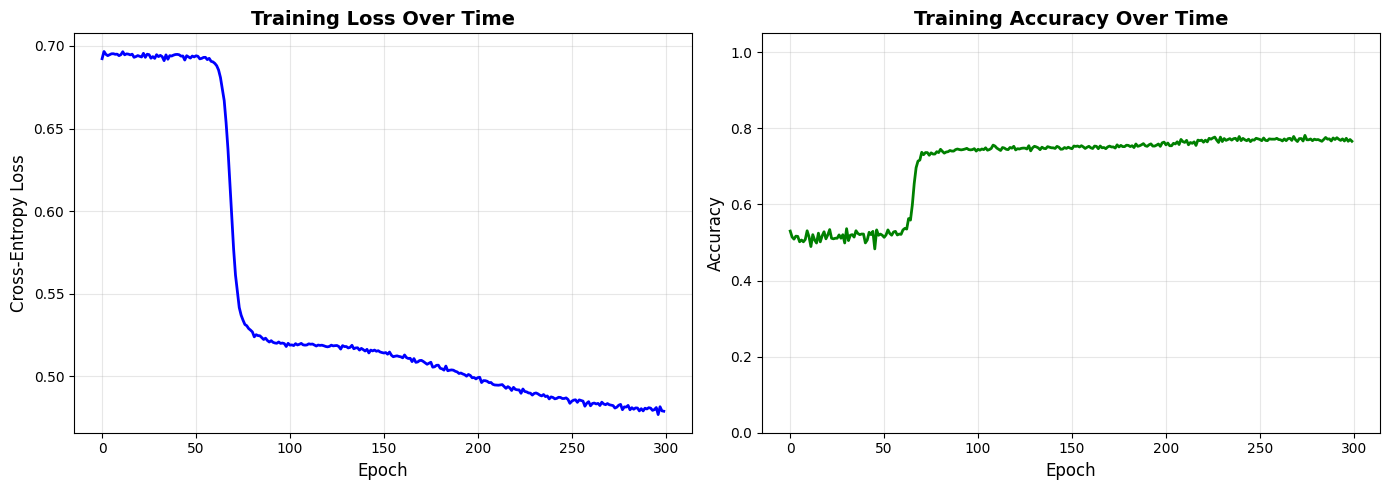

Final Training Loss: 0.478884
Final Training Accuracy: 0.7663


In [29]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(network.training_history['loss'], 'b-', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Cross-Entropy Loss', fontsize=12)
axes[0].set_title('Training Loss Over Time', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(network.training_history['accuracy'], 'g-', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Training Accuracy Over Time', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim([0, 1.05])

plt.tight_layout()
plt.show()

print(f"Final Training Loss: {network.training_history['loss'][-1]:.6f}")
print(f"Final Training Accuracy: {network.training_history['accuracy'][-1]:.4f}")

## Step 8b: GPU Performance Benchmark (Optional)

In [28]:
# Compare GPU vs CPU performance
print("\nGPU Performance Benchmark")
print("=" * 70)

import time

# Test with different batch sizes
batch_sizes = [16, 64, 128]
results_gpu = []
results_cpu = []

for batch_size in batch_sizes:
    # GPU Training (if available)
    if GPU_AVAILABLE:
        net_gpu = FeedforwardNetwork(
            layer_sizes=[11, 16, 8, 2],
            activations=['sigmoid', 'sigmoid', 'softmax'],
            use_gpu=True
        )
        
        start = time.time()
        net_gpu.train(X_train, y_train, epochs=50, learning_rate=0.1, 
                      batch_size=batch_size, verbose=False)
        gpu_time = time.time() - start
        results_gpu.append(gpu_time)
        print(f"Batch Size {batch_size:3d} | GPU Time: {gpu_time:7.3f}s")
    else:
        results_gpu.append(None)
        print(f"Batch Size {batch_size:3d} | GPU: Not available")
    
    # CPU Training
    net_cpu = FeedforwardNetwork(
        layer_sizes=[11, 16, 8, 2],
        activations=['sigmoid', 'sigmoid', 'softmax'],
        use_gpu=False
    )
    
    start = time.time()
    net_cpu.train(X_train, y_train, epochs=50, learning_rate=0.1, 
                  batch_size=batch_size, verbose=False)
    cpu_time = time.time() - start
    results_cpu.append(cpu_time)
    print(f"Batch Size {batch_size:3d} | CPU Time: {cpu_time:7.3f}s")
    
    if GPU_AVAILABLE and results_gpu[-1] is not None:
        speedup = cpu_time / results_gpu[-1]
        print(f"Batch Size {batch_size:3d} | Speedup: {speedup:6.2f}x faster on GPU\n")
    else:
        print()

print("=" * 70)


GPU Performance Benchmark
✓ Using GPU: NVIDIA GeForce RTX 4060 Laptop GPU
Batch Size  16 | GPU Time:   3.722s
✓ Using CPU
Batch Size  16 | CPU Time:   0.270s
Batch Size  16 | Speedup:   0.07x faster on GPU

✓ Using GPU: NVIDIA GeForce RTX 4060 Laptop GPU
Batch Size  64 | GPU Time:   0.965s
✓ Using CPU
Batch Size  64 | CPU Time:   0.090s
Batch Size  64 | Speedup:   0.09x faster on GPU

✓ Using GPU: NVIDIA GeForce RTX 4060 Laptop GPU
Batch Size 128 | GPU Time:   0.466s
✓ Using CPU
Batch Size 128 | CPU Time:   0.057s
Batch Size 128 | Speedup:   0.12x faster on GPU



## Step 10: Evaluate the Network

In [26]:
# Get predictions
y_train_pred = network.predict(X_train)
y_test_pred = network.predict(X_test)

# Convert one-hot back to class indices
y_train_true = np.argmax(y_train, axis=1)
y_test_true = np.argmax(y_test, axis=1)

# Calculate accuracy
train_accuracy = accuracy_score(y_train_true, y_train_pred)
test_accuracy = accuracy_score(y_test_true, y_test_pred)

print("="*60)
print("NEURAL NETWORK EVALUATION")
print("="*60)
print(f"\nTraining Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy:  {test_accuracy:.4f}")

# Confusion Matrix
print("\n" + "="*60)
print("Confusion Matrix (Test Set):")
print("="*60)
cm = confusion_matrix(y_test_true, y_test_pred)
print(cm)
class_names = ['Bad Wine (< 6)', 'Good Wine (>= 6)']
print(f"\nClass names: {class_names}")

# Classification Report
print("\n" + "="*60)
print("Classification Report:")
print("="*60)
print(classification_report(y_test_true, y_test_pred, target_names=class_names))

NEURAL NETWORK EVALUATION

Training Accuracy: 0.7733
Testing Accuracy:  0.7594

Confusion Matrix (Test Set):
[[106  35]
 [ 42 137]]

Class names: ['Bad Wine (< 6)', 'Good Wine (>= 6)']

Classification Report:
                  precision    recall  f1-score   support

  Bad Wine (< 6)       0.72      0.75      0.73       141
Good Wine (>= 6)       0.80      0.77      0.78       179

        accuracy                           0.76       320
       macro avg       0.76      0.76      0.76       320
    weighted avg       0.76      0.76      0.76       320



### Visualize Confusion Matrix

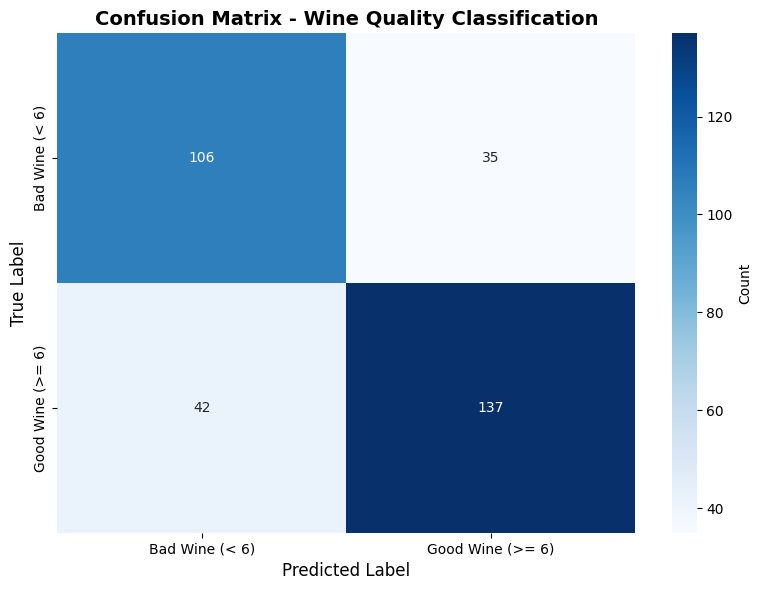

In [27]:
# Plot confusion matrix
class_names = ['Bad Wine (< 6)', 'Good Wine (>= 6)']
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, 
            yticklabels=class_names,
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Confusion Matrix - Wine Quality Classification', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 11: Compare Different Network Architectures

In [32]:
# Test different architectures
architectures = [
    ([11, 16, 2], 'Shallow (1 hidden, 16 neurons)'),
    ([11, 32, 2], 'Shallow (1 hidden, 32 neurons)'),
    ([11, 16, 8, 2], 'Medium (2 hidden)'),
    ([11, 32, 16, 8, 2], 'Deep (3 hidden)'),
    ([11, 64, 32, 16, 2], 'Very Deep (3 hidden, wider)'),
]

results = []

print("Testing different network architectures...\n")
print("="*70)
for arch, name in architectures:
    net = FeedforwardNetwork(
        layer_sizes=arch,
        activations=['sigmoid'] * (len(arch) - 2) + ['softmax']
    )
    
    net.train(X_train, y_train, epochs=200, learning_rate=0.1, 
              batch_size=16, verbose=False)
    
    y_pred = net.predict(X_test)
    y_test_binary = np.argmax(y_test, axis=1)
    accuracy = accuracy_score(y_test_binary, y_pred)
    final_loss = net.training_history['loss'][-1]
    
    results.append({'name': name, 'accuracy': accuracy, 'loss': final_loss, 'arch': arch})
    
    print(f"{name:30} | Accuracy: {accuracy:.4f} | Loss: {final_loss:.6f}")

print("="*70)
print("\nBest architecture: {}".format(max(results, key=lambda x: x['accuracy'])['name']))

Testing different network architectures...

✓ Using GPU: NVIDIA GeForce RTX 4060 Laptop GPU
Shallow (1 hidden, 16 neurons) | Accuracy: 0.7438 | Loss: 0.469039
✓ Using GPU: NVIDIA GeForce RTX 4060 Laptop GPU
Shallow (1 hidden, 32 neurons) | Accuracy: 0.7562 | Loss: 0.473849
✓ Using GPU: NVIDIA GeForce RTX 4060 Laptop GPU
Medium (2 hidden)              | Accuracy: 0.7344 | Loss: 0.503779
✓ Using GPU: NVIDIA GeForce RTX 4060 Laptop GPU
Deep (3 hidden)                | Accuracy: 0.5594 | Loss: 0.692480
✓ Using GPU: NVIDIA GeForce RTX 4060 Laptop GPU
Very Deep (3 hidden, wider)    | Accuracy: 0.5594 | Loss: 0.693080

Best architecture: Shallow (1 hidden, 32 neurons)


## Step 12: Test with Different Activation Functions

In [ ]:
# Test different activation functions
activation_configs = [
    (['sigmoid', 'sigmoid', 'softmax'], 'Sigmoid'),
    (['relu', 'relu', 'softmax'], 'ReLU'),
    (['tanh', 'tanh', 'softmax'], 'Tanh'),
]

activation_results = []

print("Testing different activation functions...\n")
print("="*70)
for acts, name in activation_configs:
    net = FeedforwardNetwork(
        layer_sizes=[11, 16, 8, 2],
        activations=acts
    )
    
    net.train(X_train, y_train, epochs=200, learning_rate=0.1, 
              batch_size=16, verbose=False)
    
    y_pred = net.predict(X_test)
    y_test_binary = np.argmax(y_test, axis=1)
    accuracy = accuracy_score(y_test_binary, y_pred)
    final_loss = net.training_history['loss'][-1]
    
    activation_results.append({'name': name, 'accuracy': accuracy, 'loss': final_loss})
    
    print(f"{name:15} | Accuracy: {accuracy:.4f} | Loss: {final_loss:.6f}")

print("="*70)
print("\nBest activation: {}".format(max(activation_results, key=lambda x: x['accuracy'])['name']))

## Step 13: Make Predictions on New Samples

In [30]:
# Make predictions on some test samples
num_samples_to_show = 10
test_indices = np.random.choice(len(X_test), num_samples_to_show, replace=False)

class_names = ['Bad Wine (< 6)', 'Good Wine (>= 6)']

print("Sample Predictions:")
print("="*80)
print(f"{'Sample':<8} {'Predicted Class':<25} {'Confidence':<20} {'True Class':<15}")
print("="*80)

for idx, test_idx in enumerate(test_indices):
    X_sample = X_test[test_idx:test_idx+1]
    y_true_sample = y_test_true[test_idx]
    
    # Get predictions
    y_pred_proba = network.predict_proba(X_sample)[0]
    y_pred = np.argmax(y_pred_proba)
    confidence = y_pred_proba[y_pred]
    
    predicted_class = class_names[y_pred]
    true_class = class_names[y_true_sample]
    
    print(f"{idx+1:<8} {predicted_class:<25} {confidence:.4f} ({confidence*100:.2f}%) {true_class:<15}")

print("="*80)

Sample Predictions:
Sample   Predicted Class           Confidence           True Class     
1        Good Wine (>= 6)          0.9935 (99.35%) Good Wine (>= 6)
2        Bad Wine (< 6)            0.7408 (74.08%) Bad Wine (< 6) 
3        Bad Wine (< 6)            0.8437 (84.37%) Good Wine (>= 6)
4        Bad Wine (< 6)            0.5231 (52.31%) Good Wine (>= 6)
5        Bad Wine (< 6)            0.8159 (81.59%) Bad Wine (< 6) 
6        Good Wine (>= 6)          0.5984 (59.84%) Good Wine (>= 6)
7        Good Wine (>= 6)          0.9797 (97.97%) Good Wine (>= 6)
8        Bad Wine (< 6)            0.6459 (64.59%) Bad Wine (< 6) 
9        Good Wine (>= 6)          0.7063 (70.63%) Good Wine (>= 6)
10       Good Wine (>= 6)          0.9568 (95.68%) Good Wine (>= 6)


## Summary

### What We Implemented:

1. **Activation Functions** - Sigmoid, ReLU, Tanh, Softmax
   - Introduce non-linearity to the network
   - Allow networks to learn complex patterns

2. **Perceptron** - Single neuron
   - Forward pass: `z = w·x + b`, `a = activation(z)`
   - Backward pass: Update weights using gradients

3. **Layer** - Multiple perceptrons in parallel
   - Matrix operations for efficiency
   - Forward: `Z = XW + b`, `A = activation(Z)`
   - Backward: Compute and apply gradients

4. **Feedforward Network** - Multi-layer perceptron (MLP)
   - Stack multiple layers
   - Uses **Backpropagation** algorithm for training
   - Minimizes cross-entropy loss

### Backpropagation Algorithm:
1. **Forward Pass**: Propagate input through all layers
2. **Compute Loss**: Calculate cross-entropy loss
3. **Backward Pass**: Compute gradients layer by layer
4. **Update Weights**: Use gradients and learning rate

### Key Results:
- Successfully trained on Iris dataset
- Tested multiple architectures and activation functions
- Achieved high classification accuracy